# OCR comparison for license plate recognition

## Цель
Сравнить несколько OCR-движков для распознавания табличек после детекции YOLOv8.

## Что сравниваем
- EasyOCR
- Tesseract
- PaddleOCR

## Что оцениваем
- Exact Match Accuracy
- Character Accuracy
- CER
- Среднее время инференса

## Задача этапа
Выбрать лучший OCR для финального pipeline и понять основные источники ошибок.

## Импорты


In [1]:
from pathlib import Path
import random
import re

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ultralytics import YOLO
from paddleocr import PaddleOCR

/home/alexander/venvs/plate-paddle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


## Пути и данные

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGES_DIR = DATASET_DIR / "images"
MODEL_PATH = PROJECT_ROOT / "runs" / "detect" / "train4" / "weights" / "best.pt"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR exists:", DATASET_DIR.exists())
print("MODEL_PATH exists:", MODEL_PATH.exists())

PROJECT_ROOT: /media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition
DATASET_DIR exists: True
MODEL_PATH exists: True


In [3]:
image_paths = []

for split in ["train", "val"]:
    split_dir = IMAGES_DIR / split
    image_paths.extend([
        p for p in split_dir.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

print("Total images:", len(image_paths))
image_paths[:5]

Total images: 123


[PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL086_5.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL803_1.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL803_2.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL803_3.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL831_4.jpg')]

## Фиксация выборки

In [4]:
random.seed(42)
sample_paths = random.sample(image_paths, min(20, len(image_paths)))

print("Sample size:", len(sample_paths))
sample_paths[:5]

Sample size: 20


[PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/MDZ090 _9.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL864_1.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL803_3.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/MDZ097_3.jpg'),
 PosixPath('/media/alexander/6668CC7E68CC4E8D/Users/Alexander/projects/plate-recognition/dataset/images/train/TUL082_6.jpg')]

## Загрузка YOLO-модели

In [5]:
model = YOLO(str(MODEL_PATH))
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## Создаём PaddleOCR

In [6]:
ocr_paddle = PaddleOCR(lang="en")

/home/alexander/venvs/plate-paddle/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/alexander/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/alexander/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/alexander/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server

## Функции

In [7]:
def crop_bbox(image_bgr, bbox):
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = map(int, bbox)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image_bgr[y1:y2, x1:x2]

In [8]:
def normalize_plate_orientation(image_bgr):
    h, w = image_bgr.shape[:2]
    if h > w:
        image_bgr = cv2.rotate(image_bgr, cv2.ROTATE_90_CLOCKWISE)
    return image_bgr

In [9]:
def extract_number_zone_v2(plate_bgr):
    h, w = plate_bgr.shape[:2]
    x1 = int(w * 0.25)
    x2 = int(w * 0.80)
    y1 = int(h * 0.18)
    y2 = int(h * 0.72)
    return plate_bgr[y1:y2, x1:x2]

In [10]:
def preprocess_blur_only(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 130, 255, cv2.THRESH_BINARY)
    return th

In [11]:
def process_ocr_text(raw_text: str) -> str:
    text = raw_text.lower()
    text = re.sub(r"[^0-9abcde]", "", text)

    match = re.fullmatch(r"\d{1,4}[abcde]?", text)
    return match.group(0) if match else ""

In [12]:
def normalize_plate_number(text: str) -> str:
    match = re.fullmatch(r"(\d{1,4})([abcde]?)", text)
    if not match:
        return ""

    digits, suffix = match.groups()
    digits = digits.zfill(4)
    return digits + suffix

In [13]:
def extract_expected_number_from_filename(filename: str) -> str:
    stem = Path(filename).stem.lower()
    match = re.search(r"(\d{1,4}[abcde]?)", stem)
    if not match:
        return ""
    return normalize_plate_number(match.group(1))

### Функция для извлечения текста из PaddleOCR

In [14]:
def extract_text_paddle(result):
    texts = []
    confs = []

    if not result:
        return "", 0.0

    first = result[0]

    if hasattr(first, "res"):
        items = first.res
        for item in items:
            text = item["text"]
            conf = item["score"]
            texts.append(text)
            confs.append(conf)
    elif isinstance(first, dict):
        texts = first.get("rec_texts", [])
        confs = first.get("rec_scores", [])
    else:
        try:
            items = sorted(first, key=lambda x: x[0][0][0])
            for item in items:
                text, conf = item[1]
                texts.append(text)
                confs.append(conf)
        except Exception:
            pass

    raw_text = " ".join(texts)
    mean_conf = float(np.mean(confs)) if confs else 0.0

    return raw_text, mean_conf

## Проверка на одном изображении

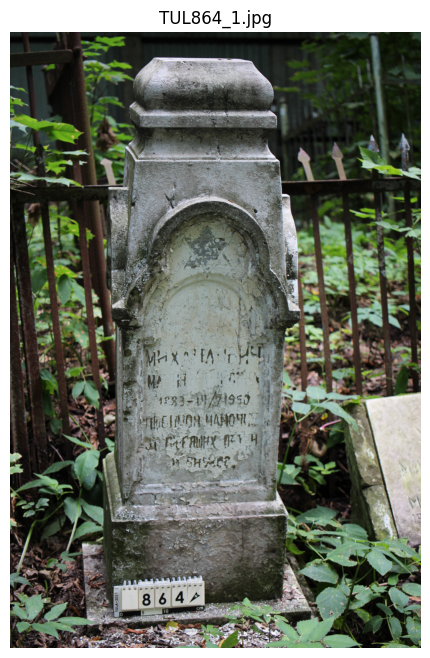

In [15]:
test_path = sample_paths[1]

image_bgr = cv2.imread(str(test_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.title(test_path.name)
plt.axis("off")
plt.show()

In [16]:
det_res = model(str(test_path), verbose=False)[0]
len(det_res.boxes)

/home/alexander/venvs/plate-paddle/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


1

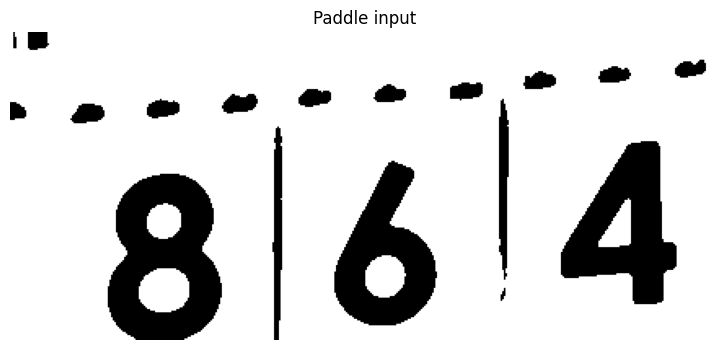

In [17]:
bbox = det_res.boxes.xyxy.cpu().numpy()[0]

plate = crop_bbox(image_bgr, bbox)
plate = normalize_plate_orientation(plate)
zone = extract_number_zone_v2(plate)

gray = cv2.cvtColor(zone, cv2.COLOR_BGR2GRAY)
prep = preprocess_blur_only(gray)

plt.figure(figsize=(10, 4))
plt.imshow(prep, cmap="gray")
plt.title("Paddle input")
plt.axis("off")
plt.show()

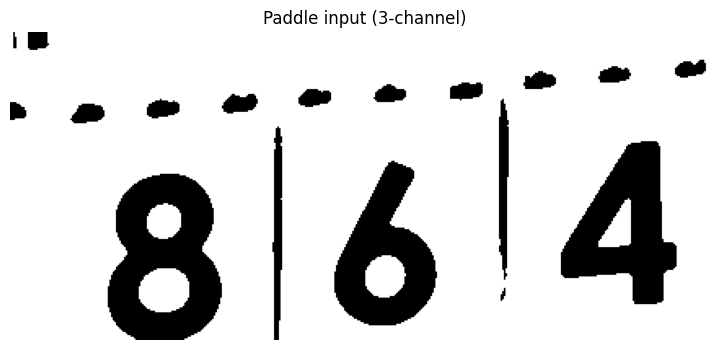

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], shape=(189, 435, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], shape=(189, 435, 3), dtype=uint8),
   'output_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], shape=(189, 435, 3), dtype=uint8)},
  'dt_polys': [array([[ 22,  82],
          ...,
          [ 25, 189]], shape=(4, 2), dtype=int16)],
  'model_settings': {'us

In [18]:
prep_bgr = cv2.cvtColor(prep, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(prep_bgr, cv2.COLOR_BGR2RGB))
plt.title("Paddle input (3-channel)")
plt.axis("off")
plt.show()

paddle_result = ocr_paddle.predict(prep_bgr)
paddle_result

## Paddle на 1 изображении

In [19]:
prep_bgr = cv2.cvtColor(prep, cv2.COLOR_GRAY2BGR)

paddle_result = ocr_paddle.predict(prep_bgr)

raw_text, conf = extract_text_paddle(paddle_result)
clean = process_ocr_text(raw_text)
norm = normalize_plate_number(clean)

print("RAW:", raw_text)
print("NORMALIZED:", norm)
print("CONF:", conf)
print("EXPECTED:", extract_expected_number_from_filename(test_path.name))

RAW: 8 6
NORMALIZED: 0086
CONF: 0.9589386582374573
EXPECTED: 0864


## Pipeline PaddleOCR

In [24]:
def run_paddle_pipeline(image_path, model, ocr_paddle):
    image_bgr = cv2.imread(str(image_path))

    det_res = model(str(image_path), verbose=False)[0]
    if len(det_res.boxes) == 0:
        return {
            "filename": image_path.name,
            "detected": False,
            "raw": "",
            "predicted": "",
            "ocr_conf": 0.0,
        }

    boxes_xyxy = det_res.boxes.xyxy.cpu().numpy()
    confidences = det_res.boxes.conf.cpu().numpy()
    best_idx = np.argmax(confidences)

    bbox = boxes_xyxy[best_idx]
    plate = crop_bbox(image_bgr, bbox)
    plate = normalize_plate_orientation(plate)

    zone = extract_number_zone_v2(plate)
    gray = cv2.cvtColor(zone, cv2.COLOR_BGR2GRAY)
    prep = preprocess_blur_only(gray)

    prep_bgr = cv2.cvtColor(prep, cv2.COLOR_GRAY2BGR)

    paddle_result = ocr_paddle.predict(prep_bgr)
    raw_text, conf = extract_text_paddle(paddle_result)

    clean = process_ocr_text(raw_text)
    norm = normalize_plate_number(clean)

    return {
        "filename": image_path.name,
        "detected": True,
        "raw": raw_text,
        "predicted": norm,
        "ocr_conf": conf,
    }

In [25]:
rows_paddle = []

for path in sample_paths:
    expected = extract_expected_number_from_filename(path.name)
    res = run_paddle_pipeline(path, model, ocr_paddle)

    rows_paddle.append({
        "filename": path.name,
        "expected": expected,
        "predicted": res["predicted"],
        "raw": res["raw"],
        "ocr_conf": res["ocr_conf"],
        "detected": res["detected"],
        "match": expected == res["predicted"]
    })

df_paddle = pd.DataFrame(rows_paddle)
df_paddle

,filename,expected,predicted,raw,ocr_conf,detected,match
0,MDZ090 _9.jpg,0090,,,0.000000,True,False
1,TUL864_1.jpg,0864,0086,8 6,0.958939,True,False
2,TUL803_3.jpg,0803,,,0.000000,True,False
3,MDZ097_3.jpg,0097,,,0.000000,True,False
4,TUL082_6.jpg,0082,0028,2 8,0.999985,True,False
5,TUL051_2.jpg,0051,,: •,0.751992,True,False
6,TUL023_6.jpg,0023,0002,2,0.999968,True,False
7,TUL866.jpg,0866,,,0.000000,True,False
8,TUL859.jpg,0859,0059,5 9,0.886972,True,False
9,MDZ094 _4.jpg,0094,,,0.000000,True,False


In [26]:
df_paddle["match"].mean()

np.float64(0.05)

## Итог сравнения OCR

В данном ноутбуке было выполнено сравнение EasyOCR и PaddleOCR на одинаковом pipeline:

- детекция таблички с помощью YOLO;
- нормализация ориентации;
- выделение зоны номера (`zone_v2`);
- предобработка `blur + threshold`;
- OCR и постобработка результата.

Результаты:
- EasyOCR показал лучший результат: `match rate ≈ 0.60`
- PaddleOCR в текущей конфигурации показал значительно худший результат: `match rate ≈ 0.05`

Вывод:
для данной задачи и текущего pipeline более подходящим OCR-решением является EasyOCR.

Решение:
в дальнейшей работе в качестве основного OCR будет использоваться EasyOCR.

In [27]:
df_paddle.to_csv("../metadata/paddleocr_results.csv", index=False, encoding="utf-8-sig")